#### **Specify the bin edges**

Sort 9 numbers between 1 and 4 into 3 bins:

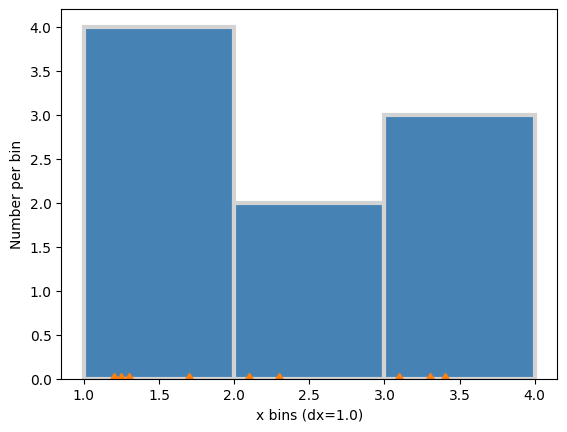

In [7]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(19680801)

xdata = np.array([1.2, 2.3, 3.3, 3.1, 1.7, 3.4, 2.1, 1.25, 1.3])
xbins = np.array([1, 2, 3, 4])

# Changing the style of the histogram bars just to make it
# very clear where the boundaries of the bins are:
style = dict(facecolor="steelblue", edgecolor="lightgray", linewidth=3)

fig, ax = plt.subplots()
ax.hist(xdata, bins=xbins, **style)

# Plot the xdata locations on the x-axis
ax.plot(xdata, 0 * xdata, "d")
ax.set_ylabel("Number per bin")
ax.set_xlabel("x bins (dx=1.0)")

plt.show()

#### **Modifying Bins**

Make the bins half as wide, will change the shape of this sparse histogram

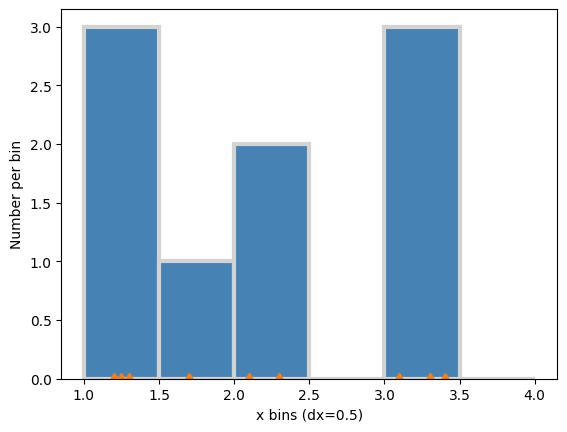

In [8]:
xbins = np.arange(1, 4.5, 0.5)

fig, ax = plt.subplots()
ax.hist(xdata, bins=xbins, **style)
ax.plot(xdata, 0 * xdata, "d")
ax.set_ylabel("Number per bin")
ax.set_xlabel("x bins (dx=0.5)")

plt.show()

#### **Choose the bins automatically OR specify a number of bins**

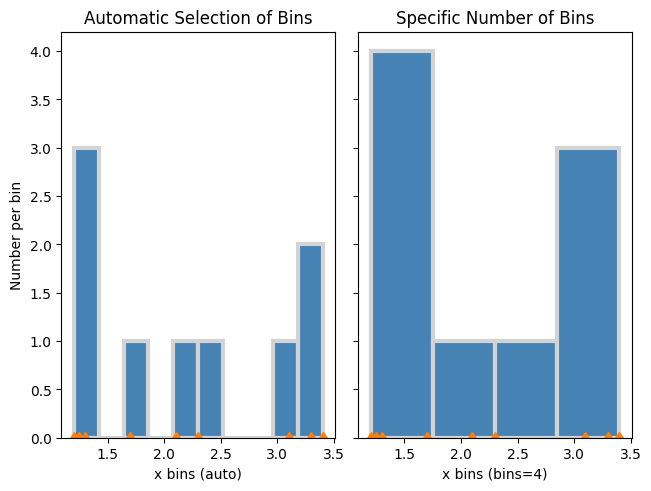

In [9]:
fig, ax = plt.subplot_mosaic([["auto", "n4"]], sharex=True, sharey=True, layout="constrained")

ax["auto"].hist(xdata, **style)
ax["auto"].plot(xdata, 0 * xdata, "d")
ax["auto"].set_ylabel("Number per bin")
ax["auto"].set_xlabel("x bins (auto)")
ax["auto"].set_title("Automatic Selection of Bins")

ax["n4"].hist(xdata, bins=4, **style)
ax["n4"].plot(xdata, 0 * xdata, "d")
ax["n4"].set_xlabel("x bins (bins=4)")
ax["n4"].set_title("Specific Number of Bins")

plt.show()

#### **Normalizing Histograms: Density & Weight**

Instead of **counts-per-bin**, now the vertical axis display **probability density**

$\Large density = \frac{counts}{(\sum{counts} \times bin width)}$

e.g for the bin [1, 1.5] the value count is 3,
there are a total of 9 values and the bin width is 0.5

$\Large density = \frac{3}{(9 \times 0.5)} = 0.67$

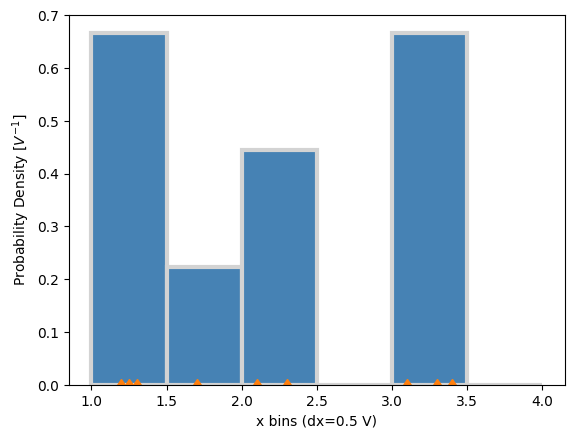

In [10]:
fig, ax = plt.subplots()
ax.hist(xdata, bins=xbins, density=True, **style)
ax.plot(xdata, 0 * xdata, "d")
ax.set_ylabel("Probability Density [$V^{-1}$]")
ax.set_xlabel("x bins (dx=0.5 V)")

plt.show()

Choose 1000 points from a normal distribution and also calculate the known PDF:

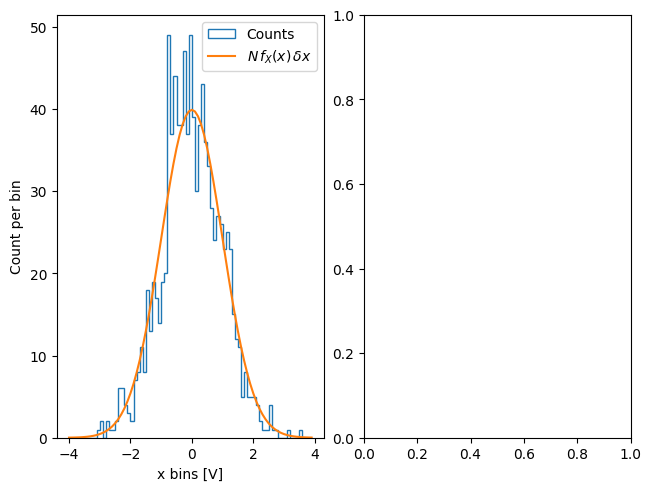

In [11]:
xdata = np.random.normal(size=1000)
xpdf = np.arange(-4, 4, 0.1)
pdf = 1 / (np.sqrt(2 * np.pi)) * np.exp(-(xpdf**2) / 2)

fig, ax = plt.subplot_mosaic([["False", "True"]], layout="constrained")

dx = 0.1
xbins = np.arange(-4, 4, dx)

ax["False"].hist(xdata, bins=xbins, density=False, histtype="step", label="Counts")

# Scale and plot the expected PDF:
ax["False"].plot(xpdf, pdf * len(xdata) * dx, label=r"$N\,f_X(x)\,\delta x$")
ax["False"].set_ylabel("Count per bin")
ax["False"].set_xlabel("x bins [V]")
ax["False"].legend()

plt.show()